Step 1: Define the Project Goal
Objective:
Analyze how accessible urban services are across Ethiopia by combining population density with administrative boundaries.
Calculate population totals per Woreda/Zone/Region and visualize accessibility gaps.


In [1]:
import os

# Show top-level datasets only
for dirname in os.listdir('/kaggle/input'):
    print(dirname)



ethiopia-high-resolution-population-density-100m
ethiopia-accessibility-analysis1
ethiopia-all-boundaries


In [2]:
!pip install geopandas folium rasterio shapely matplotlib
!pip install rasterstats

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.6/37.6 MB 45.3 MB/s eta 0:00:00:00:0100:01


In [3]:
import geopandas as gpd
import rasterio
from rasterio.enums import Resampling
from rasterstats import zonal_stats
import fiona

In [4]:
# Read Woreda boundaries
woredas = gpd.read_file(
    "/kaggle/input/ethiopia-all-boundaries/Ethiopia_All",
    layer="Eth_Woreda_2013"
)

# Reproject to metric CRS for simplification
woredas = woredas.to_crs(epsg=3857)

# Simplify geometry (memory saver)
woredas["geometry"] = woredas.geometry.simplify(
    tolerance=100,  # meters
    preserve_topology=True
)

# Back to WGS84
woredas = woredas.to_crs(epsg=4326)

# Fix invalid geometries
woredas["geometry"] = woredas.buffer(0)

# Save cleaned boundaries
woredas.to_file("/kaggle/working/ethiopia_accessibility.gpkg",
                layer="woredas_cleaned",
                driver="GPKG")

print(fiona.listlayers("/kaggle/working/ethiopia_accessibility.gpkg"))

['woredas_cleaned']


In [5]:
input_raster = "/kaggle/input/ethiopia-high-resolution-population-density-100m/eth_general_2020.tif"
resampled_raster = "/kaggle/working/eth_pop_1km.tif"

with rasterio.open(input_raster) as src:
    scale = 10  # 100m → 1km
    new_height = src.height // scale
    new_width = src.width // scale

    data = src.read(
        out_shape=(src.count, new_height, new_width),
        resampling=Resampling.average
    )

    profile = src.profile
    profile.update({
        "height": new_height,
        "width": new_width,
        "transform": src.transform * src.transform.scale(
            (src.width / new_width),
            (src.height / new_height)
        )
    })

    with rasterio.open(resampled_raster, "w", **profile) as dst:
        dst.write(data)

with rasterio.open(resampled_raster) as src:
    print(src.width, src.height)   # should be ~5400 x 4320
    print(src.res)                 # ~0.00278° (~1km)

5400 4320
(0.0027777777777800118, 0.0027777777777800118)


In [6]:
# Load cleaned Woredas
woredas = gpd.read_file("/kaggle/working/ethiopia_accessibility.gpkg",
                        layer="woredas_cleaned")

# Compute zonal statistics
stats = zonal_stats(
    woredas,
    resampled_raster,
    stats=["sum", "mean"],
    nodata=-9999
)

# Attach results
woredas["pop_sum"] = [s["sum"] for s in stats]
woredas["pop_mean_density"] = [s["mean"] for s in stats]

# Save enriched Woredas
woredas.to_file("/kaggle/working/ethiopia_accessibility.gpkg",
                layer="woredas_population",
                driver="GPKG")

print(fiona.listlayers("/kaggle/working/ethiopia_accessibility.gpkg"))

['woredas_cleaned', 'woredas_population']


In [7]:
import geopandas as gpd

# Load enriched Woredas
woredas_pop = gpd.read_file("/kaggle/working/ethiopia_accessibility.gpkg",
                            layer="woredas_population")

# Drop geometry for CSV export
woredas_summary = woredas_pop.drop(columns="geometry")

# Save to CSV
woredas_summary.to_csv("/kaggle/working/woredas_population_summary.csv", index=False)

In [8]:
# Load Zones
zones = gpd.read_file("/kaggle/input/ethiopia-all-boundaries/Ethiopia_All",
                      layer="Eth_Zone_2013")

# Reproject Zones to match Woredas CRS
zones = zones.to_crs(woredas_pop.crs)

# Spatial join
wz_join = gpd.sjoin(woredas_pop, zones, how="left", predicate="intersects")

# Group by the correct column name from the joined dataframe
zones_summary = wz_join.groupby("ZONENAME_right")[["pop_sum", "pop_mean_density"]].sum().reset_index()

# Export to CSV
zones_summary.to_csv("/kaggle/working/zones_population_summary.csv", index=False)

print(zones_summary.head())

  ZONENAME_right       pop_sum  pop_mean_density
0          Afder  4.757470e+05       1531.530849
1         Agnuak  2.322353e+05       1389.827102
2          Alaba  5.063714e+05        163.944331
3           Arsi  1.488751e+06        490.823775
4          Asosa  2.756220e+05        203.954251


In [9]:
import geopandas as gpd

# Load Regions
regions = gpd.read_file("/kaggle/input/ethiopia-all-boundaries/Ethiopia_All",
                        layer="Eth_Region_2013")

# Reproject Regions to match Woredas CRS
regions = regions.to_crs(woredas_pop.crs)

# Spatial join: assign Woredas to Regions
wr_join = gpd.sjoin(woredas_pop, regions, how="left", predicate="intersects")

# Group by Region name (from the joined dataframe)
regions_summary = wr_join.groupby("REGIONNAME_right")[["pop_sum", "pop_mean_density"]].sum().reset_index()

# Export to CSV
regions_summary.to_csv("/kaggle/working/regions_population_summary.csv", index=False)

print(regions_summary.head())

   REGIONNAME_right       pop_sum  pop_mean_density
0       Addis Ababa  1.975868e+05        384.926357
1              Afar  1.394627e+06       6328.055658
2            Amhara  5.897246e+06       4103.040027
3  Beneshangul Gumu  9.711490e+05        634.486474
4         Dire Dawa  2.421186e+05        216.517083


In [10]:
import pandas as pd


# Load Regions summary
regions_summary = pd.read_csv("/kaggle/working/regions_population_summary.csv")

print(regions_summary.head())
print(regions_summary.columns)

   REGIONNAME_right       pop_sum  pop_mean_density
0       Addis Ababa  1.975868e+05        384.926357
1              Afar  1.394627e+06       6328.055658
2            Amhara  5.897246e+06       4103.040027
3  Beneshangul Gumu  9.711490e+05        634.486474
4         Dire Dawa  2.421186e+05        216.517083
Index(['REGIONNAME_right', 'pop_sum', 'pop_mean_density'], dtype='object')


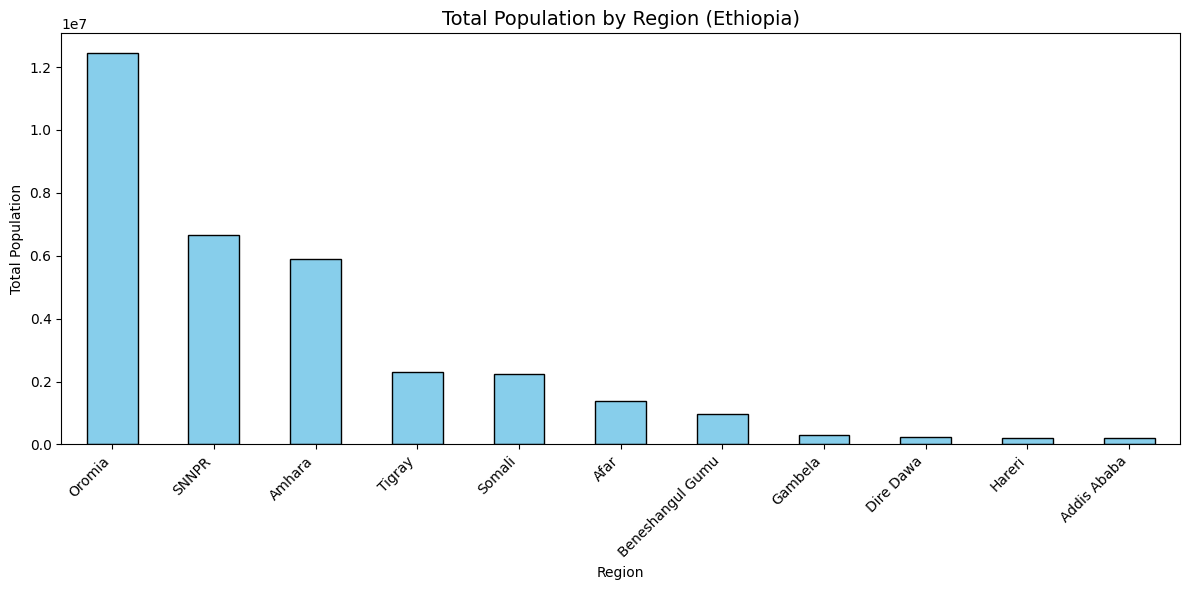

In [11]:
import matplotlib.pyplot as plt

# Group by Region and sum population
region_pop = regions_summary.groupby("REGIONNAME_right")["pop_sum"].sum().sort_values(ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
region_pop.plot(kind="bar", ax=ax, color="skyblue", edgecolor="black")

ax.set_title("Total Population by Region (Ethiopia)", fontsize=14)
ax.set_xlabel("Region")
ax.set_ylabel("Total Population")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [12]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Load Regions shapefile
regions = gpd.read_file("/kaggle/input/ethiopia-all-boundaries/Ethiopia_All",
                        layer="Eth_Region_2013")

# Reproject to match Woredas CRS (EPSG:4326)
regions = regions.to_crs("EPSG:4326")

# Load Regions population summary
regions_summary = pd.read_csv("/kaggle/working/regions_population_summary.csv")

# Merge shapefile with population summary
regions_merged = regions.merge(regions_summary,
                               left_on="REGIONNAME",   # adjust if needed
                               right_on="REGIONNAME_right",
                               how="left")


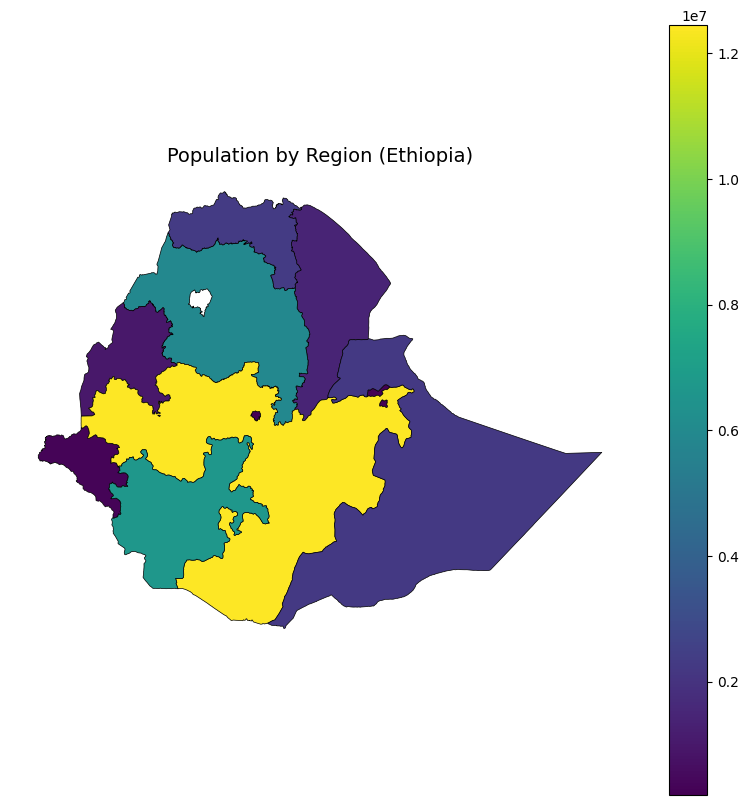

In [13]:
# Plot choropleth of population totals
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
regions_merged.plot(column="pop_sum",
                    cmap="viridis",
                    legend=True,
                    ax=ax,
                    edgecolor="black",
                    linewidth=0.5)

ax.set_title("Population by Region (Ethiopia)", fontsize=14)
ax.axis("off")
plt.show()

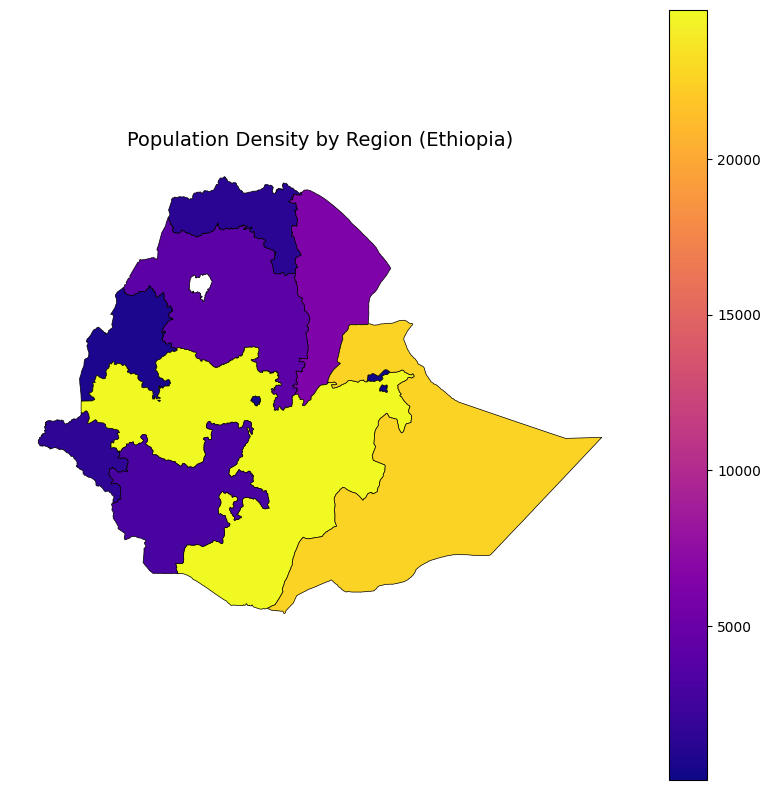

In [14]:
# Plot choropleth of population density
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
regions_merged.plot(column="pop_mean_density",
                    cmap="plasma",
                    legend=True,
                    ax=ax,
                    edgecolor="black",
                    linewidth=0.5)

ax.set_title("Population Density by Region (Ethiopia)", fontsize=14)
ax.axis("off")
plt.show()

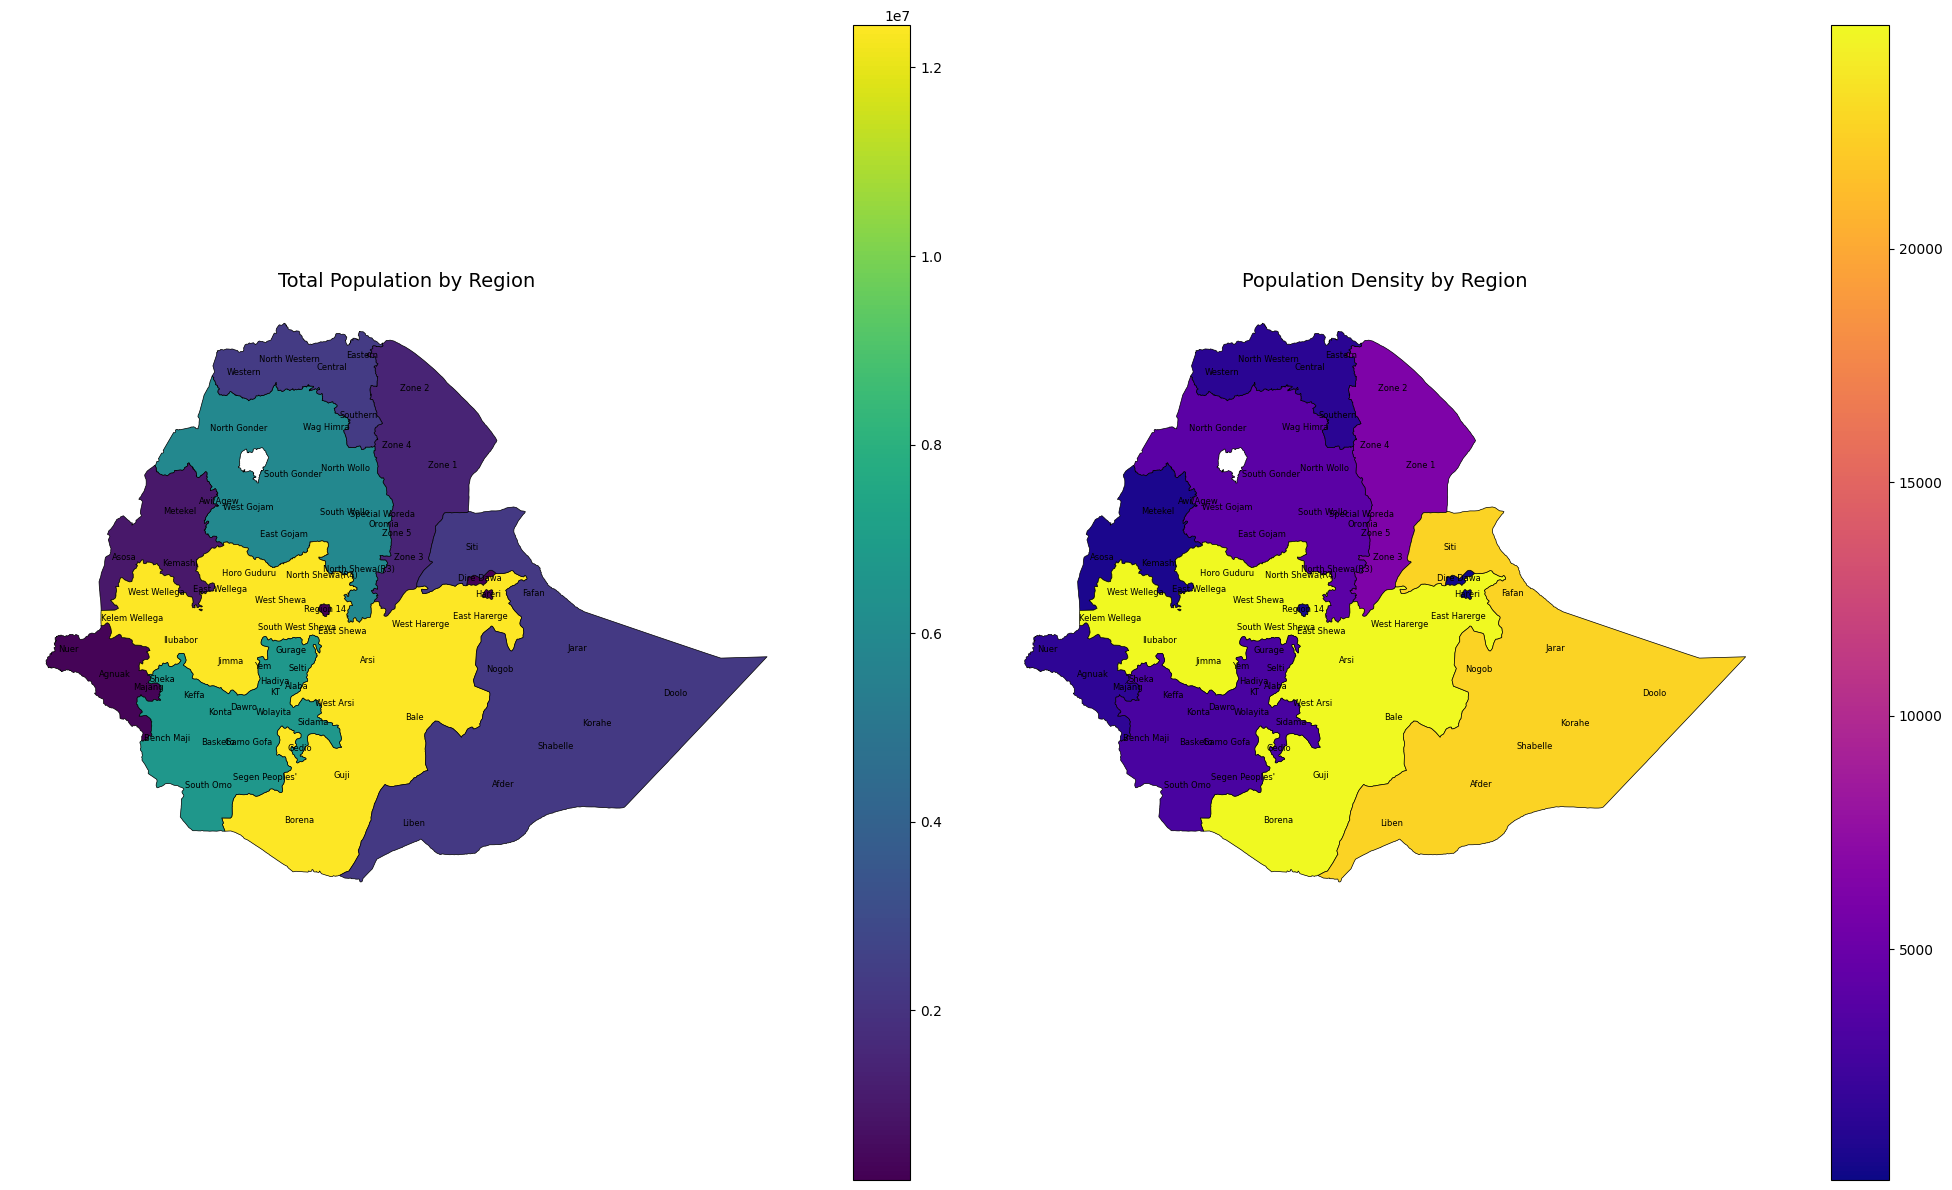

In [15]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Create side-by-side figure
fig, axes = plt.subplots(1, 2, figsize=(20, 12))

# Map 1: Total population
regions_merged.plot(column="pop_sum", cmap="viridis", legend=True,
                    ax=axes[0], edgecolor="black", linewidth=0.5)
axes[0].set_title("Total Population by Region", fontsize=14)
axes[0].axis("off")

# Add Zone labels to Map 1
for idx, row in zones.iterrows():
    centroid = row.geometry.centroid
    axes[0].text(centroid.x, centroid.y, row["ZONENAME"],
                 fontsize=6, ha="center", va="center")

# Map 2: Population density
regions_merged.plot(column="pop_mean_density", cmap="plasma", legend=True,
                    ax=axes[1], edgecolor="black", linewidth=0.5)
axes[1].set_title("Population Density by Region", fontsize=14)
axes[1].axis("off")

# Add Zone labels to Map 2
for idx, row in zones.iterrows():
    centroid = row.geometry.centroid
    axes[1].text(centroid.x, centroid.y, row["ZONENAME"],
                 fontsize=6, ha="center", va="center")

plt.tight_layout()
plt.show()




